In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt


c:\Users\abhin\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
path = tf.keras.utils.get_file('shakespeare.txt)',"https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt")

text = open(path,'r',encoding='utf-8').read()

text = text.lower()

text[:500]

"first citizen:\nbefore we proceed any further, hear me speak.\n\nall:\nspeak, speak.\n\nfirst citizen:\nyou are all resolved rather to die than to famish?\n\nall:\nresolved. resolved.\n\nfirst citizen:\nfirst, you know caius marcius is chief enemy to the people.\n\nall:\nwe know't, we know't.\n\nfirst citizen:\nlet us kill him, and we'll have corn at our own price.\nis't a verdict?\n\nall:\nno more talking on't; let it be done: away, away!\n\nsecond citizen:\none word, good citizens.\n\nfirst citizen:\nwe are accounted poor"

In [4]:
print("Total characters",len(text))
words = text.split()
print("Total words",len(text.split()))

Total characters 1115394
Total words 202651


In [5]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
word_indix = tokenizer.word_index
vocab_size = len(word_indix)+1
print("vocabulary",vocab_size)


vocabulary 12633


In [6]:
for word, index in list(word_indix.items()):
    print(word,":",index)

the : 1
and : 2
to : 3
i : 4
of : 5
you : 6
my : 7
a : 8
that : 9
in : 10
is : 11
not : 12
for : 13
with : 14
me : 15
it : 16
be : 17
your : 18
his : 19
but : 20
this : 21
he : 22
have : 23
as : 24
thou : 25
him : 26
so : 27
what : 28
thy : 29
will : 30
by : 31
no : 32
all : 33
king : 34
we : 35
shall : 36
her : 37
if : 38
our : 39
are : 40
do : 41
thee : 42
lord : 43
now : 44
on : 45
good : 46
from : 47
come : 48
sir : 49
or : 50
which : 51
more : 52
then : 53
at : 54
o : 55
would : 56
was : 57
they : 58
how : 59
well : 60
here : 61
she : 62
than : 63
their : 64
them : 65
duke : 66
am : 67
hath : 68
say : 69
let : 70
when : 71
one : 72
i'll : 73
go : 74
love : 75
were : 76
may : 77
us : 78
make : 79
like : 80
upon : 81
yet : 82
richard : 83
there : 84
must : 85
should : 86
an : 87
first : 88
queen : 89
why : 90
know : 91
had : 92
man : 93
did : 94
'tis : 95
where : 96
see : 97
some : 98
too : 99
death : 100
give : 101
speak : 102
these : 103
who : 104
take : 105
edward : 106
up : 107


In [7]:
sequences = tokenizer.texts_to_sequences([text])[0]
print(sequences[:10])

[88, 269, 139, 35, 969, 143, 668, 127, 15, 102]


In [8]:
lines = text.split('\n')
input_sequences = []

for line in lines:
    # convert line to sequence of numbers
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1,len(token_list)):
        n_gram_sequences = token_list[:i+1]
        input_sequences.append(n_gram_sequences)

print("Total sequences",len(input_sequences))


Total sequences 171312


In [9]:
max_sequence_len = max([len(x) for x in input_sequences])
print("Maximum sequence length:",max_sequence_len)
input_sequences=np.array(
    pad_sequences(
        input_sequences,
        maxlen = max_sequence_len,
        padding = 'pre'
    )
)

Maximum sequence length: 16


In [10]:
x = input_sequences[:,:-1]
y = input_sequences[:,-1]
print("x shape",x.shape)
print("y shape",y.shape)

x shape (171312, 15)
y shape (171312,)


In [11]:
y = tf.keras.utils.to_categorical(y,num_classes=vocab_size)
print("y shape after one hot encoding",y.shape)

y shape after one hot encoding (171312, 12633)


In [12]:
# Import model layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

In [13]:
#create the model
model = Sequential()
#input layer
model.add(Input(shape = (max_sequence_len - 1,)))
#embedding layer
model.add(Embedding(input_dim = vocab_size,output_dim = 100))

#LSTM layer
model.add(LSTM(150))
#output layer
model.add(Dense(vocab_size,activation = 'softmax'))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 100)        │     1,263,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12633)          │     1,907,583 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,321,483 (12.67 MB)

 Trainable params: 3,321,483 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#compile model
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [15]:
#train the LSTM model
hisory = model.fit(
    x,y,
    epochs = 2,
    batch_size = 128,
    validation_split = 0.2
)

Epoch 1/2
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 98s 88ms/step - accuracy: 0.0378 - loss: 6.8928 - val_accuracy: 0.0372 - val_loss: 6.8115
Epoch 2/2
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 90s 84ms/step - accuracy: 0.0617 - loss: 6.3958 - val_accuracy: 0.0717 - val_loss: 6.6210


Epoch 1/2
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 103s 95ms/step - accuracy: 0.0864 - loss: 6.0770 - val_accuracy: 0.0807 - val_loss: 6.5634
Epoch 2/2
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 95s 89ms/step - accuracy: 0.0981 - loss: 5.8458 - val_accuracy: 0.0834 - val_loss: 6.5554
Input to be or
predict_next_word to


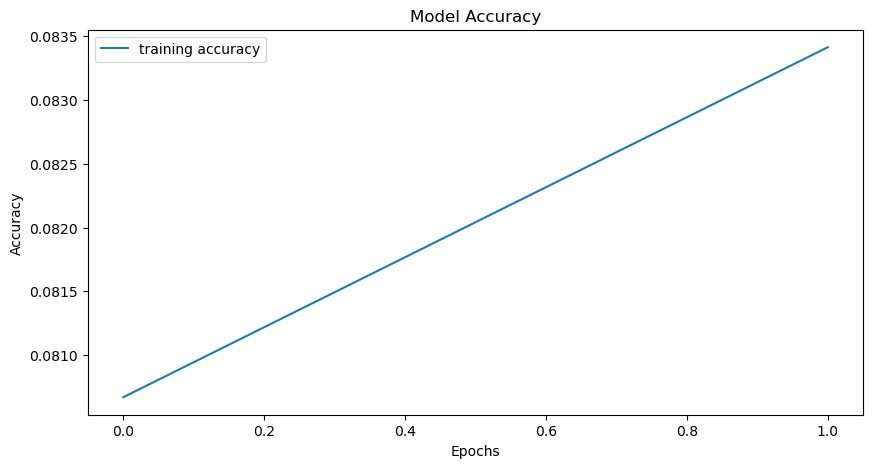

In [16]:
plt.figure(figsize=(10,5))
# train the LSTM model
history = model.fit(
     x, y,
     epochs=2,
     batch_size=128,
     validation_split=0.2
)
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel('Accuracy')
plt.legend([
    'training accuracy',
    'validation accuracy']
)
# Next word prediction 

def predict_next_word(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences(
        [token_list],
        maxlen = max_sequence_len-1,
        padding = 'pre'
    )
    predicted = model.predict(
        token_list,
        verbose = 0
        )
    predicted_word_index = np.argmax(
        predicted,
        axis=-1
    )[0]

    output_word = ""
    for word, index in tokenizer.word_index.items():
       if index == predicted_word_index:
            output_word = word
            break
    return output_word
seed = "to be or"
next_word = predict_next_word(seed)
print("Input",seed)
print("predict_next_word",next_word)